## 0. Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from rapidfuzz import process

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA



## 1. Data Loading

In [ ]:
file_path = "../data/raw/Observations 2012-2025.xlsx"
#retrieve the number of sheets
print("number of sheets:", pd.ExcelFile(file_path).sheet_names)

df_species = pd.read_excel(file_path, sheet_name='ESPECES', header=None, usecols=[2, 3, 4])
df_species.columns = ['french_name', 'scientific_name', 'status']
# df_species.isna().sum()
# status has a missing value
df_species.head()

df_gps = pd.read_excel(file_path, sheet_name='GPS-MILIEU', header=1, usecols=[2, 3, 4, 5, 6, 7])
df_gps.columns = ['transect', 'X', 'Y', 'habitat', 'transect_id', 'point_id']
# df_gps.isna().sum()
# 0 missing values
df_gps.head()

df_obs = pd.read_excel(file_path, sheet_name='NOM FRANÇAIS', skiprows=[0, 1], header=0)
df_obs.columns = [
        'observer',              # Observer name
        'dept_code',             # Department code  
        'transect',              # Transect name
        'date',                  # Date
        'visit_number',          # 1st, 2nd or 3rd visit
        'clouds',                # Cloud cover
        'rain',                  # Rain intensity
        'wind',                  # Wind strength
        'visibility',            # Visibility
        'point',                 # Point number
        'start_time',            # Start time
        'species',               # Species name
        
        # Contact distances
        'auditory_0_25m',       
        'visual_0_25m',        
        'auditory_25_50m',       
        'visual_25_50m',   
        'auditory_50_100m', 
        'visual_50_100m',     
        'auditory_100m_plus', 
        'visual_100m_plus',   
        
        # Flight
        'flight',
        
        # Totals (4 columns)
        'auditory_total',   
        'visual__no_flight_total',         
        'auditory_visual_no_flight_total',
        'auditory_visual_with_flight_total',
        
        #Notes
        'Notes'
]
df_obs['date'] = pd.to_datetime(df_obs['date'])
df_obs.head()

number of sheets: ['ESPECES', 'GPS-MILIEU', 'NOM FRANÇAIS']


,observer,dept_code,transect,date,visit_number,clouds,rain,wind,visibility,point,...,auditory_50_100m,visual_50_100m,auditory_100m_plus,visual_100m_plus,flight,auditory_total,visual__no_flight_total,auditory_visual_no_flight_total,auditory_visual_with_flight_total,Notes
0,BELFAN David,972.0,Fond l'Etang,2014-04-12,1,2,1.0,1.0,1.0,1,...,NaN,NaN,NaN,NaN,NaN,1.0,0.0,1,1.0,NaN
1,BELFAN David,972.0,Fond l'Etang,2014-04-12,1,2,1.0,1.0,1.0,1,...,NaN,NaN,NaN,NaN,NaN,0.0,1.0,1,1.0,NaN
2,BELFAN David,972.0,Fond l'Etang,2014-04-12,1,2,1.0,1.0,1.0,1,...,NaN,NaN,NaN,NaN,NaN,0.0,2.0,2,2.0,NaN
3,BELFAN David,972.0,Fond l'Etang,2014-04-12,1,2,1.0,1.0,1.0,1,...,NaN,NaN,NaN,NaN,NaN,1.0,0.0,1,1.0,NaN
4,BELFAN David,972.0,Fond l'Etang,2014-04-12,1,2,1.0,1.0,1.0,1,...,NaN,NaN,NaN,NaN,NaN,1.0,0.0,1,1.0,NaN


In [ ]:
obs_transects = set(df_obs['transect'].unique())
gps_transects = set(df_gps['transect'].unique())
print(obs_transects - gps_transects)  # transects dans obs mais pas dans gps


{'BORELIE', 'Desmarinière', 'Forêt La Philippe', 'Forêt La Reculée', 'Fond Baron ', 'BLIN', 'MORNE ACA', 'ANSE COULEUVRE', 'Tunnel Didier '}


In [ ]:
# Corriger les transects mal orthographiés dans df_obs


df_obs['transect'] = df_obs['transect'].str.strip().str.lower()
df_gps['transect'] = df_gps['transect'].str.strip().str.lower()

obs_transects = df_obs['transect'].unique()
gps_transects = df_gps['transect'].unique()

mapping = {}
for obs_name in obs_transects:
    match, score, _ = process.extractOne(obs_name, gps_transects)
    if score >= 90 and score < 100:  # 100 = exact, 90+ = correspondance probable
        mapping[obs_name] = match
        print(f"Correction: {obs_name} -> {match} (score={score})")

df_obs['transect'] = df_obs['transect'].replace(mapping)

missing_after = set(df_obs['transect'].unique()) - set(df_gps['transect'].unique())
if missing_after:
    print("Transects encore manquants :", missing_after)
else:
    print("Tous les transects correspondent maintenant à df_gps !")


Correction: desmarinière -> desmarinières (score=96.0)
Tous les transects correspondent maintenant à df_gps !


In [ ]:
df_obs_merged = df_obs.merge(
        df_species, 
        left_on='species', 
        right_on='french_name', 
        how='left',
        suffixes=('', '_species')
    )
#transect_habitat = df_gps.groupby('transect')['habitat'].first().reset_index()
#df_full = df_obs_merged.merge(
#     transect_habitat,
#     on='transect',
#     how='left'
#)
#Un transect peut avoir plusieurs habitats selon les points, on merge donc avec les points

# Extraire le numéro après le P
#df_gps['point'] = df_gps['point_id'].str.extract(r'P(\d+)')[0]
#missing_points = df_gps[df_gps['point'].isna()]
#print(missing_points)

df_gps['point_id'] = df_gps['point_id'].replace('SIPI', 'S1P1')

df_gps['point'] = df_gps['point_id'].str.extract(r'P(\d+)')[0].astype(int)
df_obs['point'] = df_obs['point'].astype(int)

df_full = df_obs_merged.merge(
    df_gps[['transect', 'point', 'X', 'Y', 'habitat']],
    on=['transect', 'point'],
    how='left'
)



## 2. Dataset Structure

In [ ]:
# Table dimensions
print("="*60)
print("TABLE DIMENSIONS")
print("="*60)

print(f"\n1. SPECIES table:")
print(f"   - {len(df_species)} species")
print(f"   - {df_species['status'].nunique()} status categories")

print(f"\n2. GPS-MILIEU table:")
print(f"   - {len(df_gps)} observation points")
print(f"   - {df_gps['transect'].nunique()} transects")
print(f"   - {df_gps['habitat'].nunique()} habitat types")

print(f"\n3. OBSERVATIONS table:")
print(f"   - {len(df_obs):,} raw observations")
print(f"   - {len(df_full):,} enriched observations")
print(f"   - {df_full.shape[1]} columns")

TABLE DIMENSIONS

1. SPECIES table:
   - 87 species
   - 8 status categories

2. GPS-MILIEU table:
   - 650 observation points
   - 65 transects
   - 7 habitat types

3. OBSERVATIONS table:
   - 114,495 raw observations
   - 115,304 enriched observations
   - 32 columns


## DATA CLEANUP

In [ ]:
#Drop si on ne sait pas ce qui a été observé
df_full = df_full.dropna(subset=['french_name', 'scientific_name'], how='all')

In [ ]:
# Remplacer les valeurs manquantes dans clouds, rain, wind, visibility (itératif avec RandomForest)

cols_to_impute = ['clouds', 'rain', 'wind', 'visibility']

for c in cols_to_impute:
    df_full[c] = pd.to_numeric(df_full[c], errors='coerce')


data_to_impute = df_full[cols_to_impute]

imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=100, random_state=42),
    max_iter=10,
    random_state=42
)
df_full[cols_to_impute] = imputer.fit_transform(df_full[cols_to_impute])

print(df_full[cols_to_impute].isna().sum())

imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=100, random_state=42),
    max_iter=10,
    random_state=42
)

data_imputed = imputer.fit_transform(data_to_impute)

df_full[cols_to_impute] = data_imputed

df_full

clouds        0
rain          0
wind          0
visibility    0
dtype: int64


,observer,dept_code,transect,date,visit_number,clouds,rain,wind,visibility,point,...,visual__no_flight_total,auditory_visual_no_flight_total,auditory_visual_with_flight_total,Notes,french_name,scientific_name,status,X,Y,habitat
0,BELFAN David,972.0,fond l'etang,2014-04-12,1,2.0,1.0,1.0,1.0,1,...,0.0,1,1.0,NaN,Sucrier à ventre jaune,Coereba flaveola martinicana,Autochtone,706274,1624126,Forêt humide
1,BELFAN David,972.0,fond l'etang,2014-04-12,1,2.0,1.0,1.0,1.0,1,...,1.0,1,1.0,NaN,Sporophile cici,Melanospiza bicolor ou Tiaris bicolor,Autochtone,706274,1624126,Forêt humide
2,BELFAN David,972.0,fond l'etang,2014-04-12,1,2.0,1.0,1.0,1.0,1,...,2.0,2,2.0,NaN,Colibri falle-vert,Eulampis h. holosericeus,Endémique des Petites Antilles,706274,1624126,Forêt humide
3,BELFAN David,972.0,fond l'etang,2014-04-12,1,2.0,1.0,1.0,1.0,1,...,0.0,1,1.0,NaN,Elénie siffleuse,Elaenia m. martinica,Autochtone,706274,1624126,Forêt humide
4,BELFAN David,972.0,fond l'etang,2014-04-12,1,2.0,1.0,1.0,1.0,1,...,0.0,1,1.0,NaN,Coulicou manioc,Coccyzus minor,Autochtone,706274,1624126,Forêt humide
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115299,MAUGEE Lévy,972.0,post-colon,2025-05-01,1,2.0,1.0,1.0,1.0,10,...,0.0,2,2.0,NaN,Sporophile rougegorge,Loxigilla n. noctis,Endémique des Petites Antilles,708778,1621356,Périurbain
115300,MAUGEE Lévy,972.0,post-colon,2025-05-01,1,2.0,1.0,1.0,1.0,10,...,0.0,1,1.0,NaN,Saltator gros-bec,Saltator a. albicollis,Autochtone,708778,1621356,Périurbain
115301,MAUGEE Lévy,972.0,post-colon,2025-05-01,1,2.0,1.0,1.0,1.0,10,...,0.0,2,2.0,NaN,Sucrier à ventre jaune,Coereba flaveola martinicana,Autochtone,708778,1621356,Périurbain
115302,MAUGEE Lévy,972.0,post-colon,2025-05-01,1,2.0,1.0,1.0,1.0,10,...,0.0,3,3.0,NaN,Viréo à moustaches,Vireo altiloquus barbadensis,Autochtone,708778,1621356,Périurbain


In [ ]:
# remplacer les valeurs manquantes dans les colonnes de comptage par 0 + recalcul des totaux

auditory_cols = ['auditory_0_25m', 'auditory_25_50m', 'auditory_50_100m', 'auditory_100m_plus']
visual_cols = ['visual_0_25m', 'visual_25_50m', 'visual_50_100m', 'visual_100m_plus']
flight = ['flight']
for c in auditory_cols + visual_cols + flight:
    df_full[c] = pd.to_numeric(df_full[c], errors='coerce')
    
df_full[ auditory_cols + visual_cols + flight] = df_full[ auditory_cols + visual_cols + flight].fillna(0)

df_full.head()

totals = ['auditory_total', 'visual__no_flight_total', 'auditory_visual_no_flight_total', 'auditory_visual_with_flight_total']
for c in totals:
    df_full[c] = pd.to_numeric(df_full[c], errors='coerce')
    
df_full['auditory_total'] = df_full[auditory_cols].sum(axis=1)
df_full['visual__no_flight_total'] = df_full[visual_cols].sum(axis=1)
df_full['auditory_visual_no_flight_total'] = df_full[auditory_cols + visual_cols].sum(axis=1)
df_full['auditory_visual_with_flight_total'] = df_full[auditory_cols + visual_cols + ['flight']].sum(axis=1)

In [ ]:
nan_cols = df_full.columns[df_full.isna().any()]
print(df_full[nan_cols].isna().sum())

dept_code         2
Notes        103212
status           55
dtype: int64


In [ ]:
df_full.columns

Index(['observer', 'dept_code', 'transect', 'date', 'visit_number', 'clouds',
       'rain', 'wind', 'visibility', 'point', 'start_time', 'species',
       'auditory_0_25m', 'visual_0_25m', 'auditory_25_50m', 'visual_25_50m',
       'auditory_50_100m', 'visual_50_100m', 'auditory_100m_plus',
       'visual_100m_plus', 'flight', 'auditory_total',
       'visual__no_flight_total', 'auditory_visual_no_flight_total',
       'auditory_visual_with_flight_total', 'Notes', 'french_name',
       'scientific_name', 'status', 'X', 'Y', 'habitat'],
      dtype='object')

In [ ]:
nan_cols = df_full.columns[df_full.isna().any()]
print(df_full[nan_cols].isna().sum())

dept_code         2
Notes        103212
status           55
dtype: int64


In [ ]:
df_full['Notes'].unique()


array([nan, 'en formation  SOPHIE Stéphane/ ELY-MARIUS Séverine',
       'Compagnonnage par Beatriz Conde  ', 'Banane 100% coupé',
       "Beaucoup d'ordure et carcasse de voiture",
       'Camping de plusiers personnes sur ce site',
       'Végetation très secs', 'COMPAGNONNAGE PAR BEATRIZ CONDE',
       'CARCASSE DE VOITURE',
       'Les PRODOM ont trouvé un nouveau site de nidification la toiture du lycée',
       'Canne 100% coupé', 'Canne 70% coupé', "Aménagement d'un parking",
       'DORTOIRE', 'Canne à sucre  100% coupé', 'Canne à sucre 50% coupé',
       'FAIT PAR BEATRIZ CONDE', "Accompagner par Caroll-Ann' Portel",
       'AU NID',
       'Oiseau dans la peripherie du camps de canne- Canne a sucre basse',
       'Canne basse', 'Sans canne 50% et canne à sucre basse 50%',
       'Pas de canne', 'Bassin de traitement',
       'COMPAGNONAGE AVEC B.CONDE', "SUR L'ILET BOISSEAU",
       "Presence d'iguane", 'Compagnonnage par Beatriz CONDE',
       'COMPAGNONNAGE PAR BEATRIZ COND

## Clustering : Regroupons les espèces qui ont des profils similaires de détection et d’habitat.

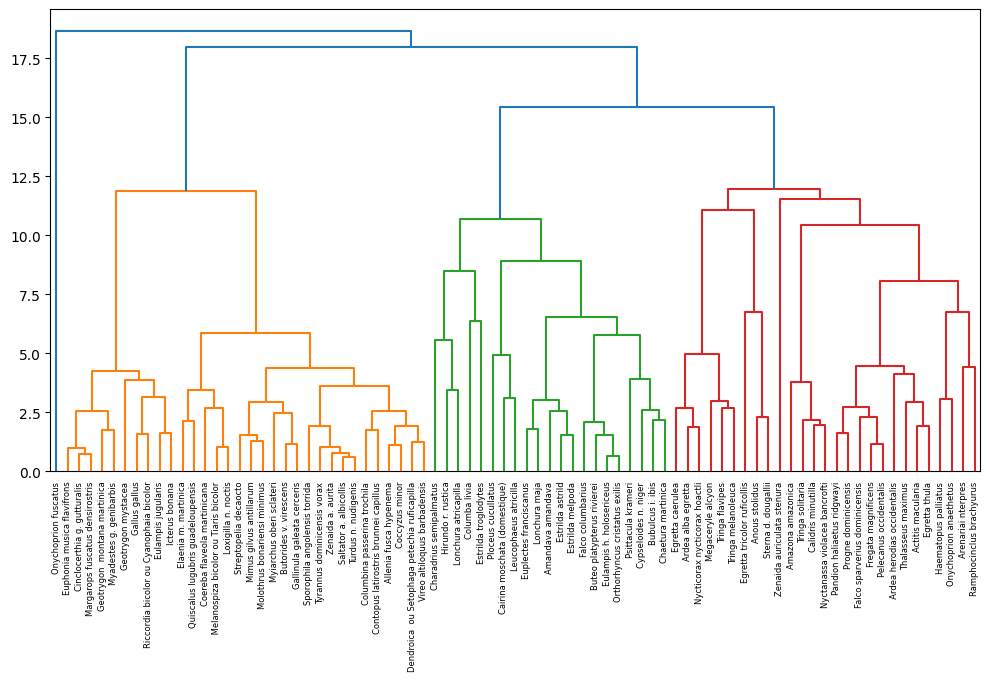

In [ ]:
detection_cols = [
    'auditory_0_25m', 'auditory_25_50m', 'auditory_50_100m', 'auditory_100m_plus',
    'visual_0_25m', 'visual_25_50m', 'visual_50_100m', 'visual_100m_plus',
    'flight'
]

habitat_dummies = pd.get_dummies(df_full['habitat'], prefix='habitat')
df_cluster = pd.concat([df_full[detection_cols], habitat_dummies], axis=1)

df_species_cluster = df_cluster.groupby(df_full['scientific_name']).mean()



scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_species_cluster)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_species_cluster)

Z = linkage(X_scaled, method='ward')
plt.figure(figsize=(12, 6))
dendrogram(Z, labels=df_species_cluster.index, leaf_rotation=90)
plt.show()


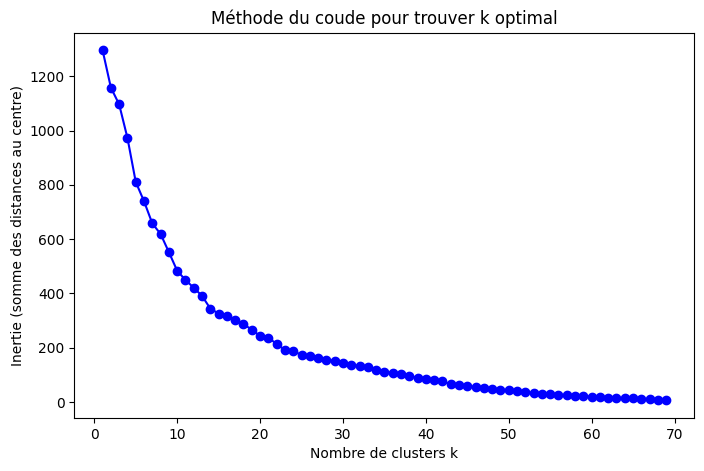

In [ ]:
inertia = []
K = range(1, 70)  # tester de 1 à 14 clusters
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Nombre de clusters k')
plt.ylabel('Inertie (somme des distances au centre)')
plt.title('Méthode du coude pour trouver k optimal')
plt.show()


C:\Users\zizou\AppData\Local\Temp\ipykernel_3392\3647295126.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab20', n_clusters)  # 'tab20' permet plus de couleurs, interpolé si >20


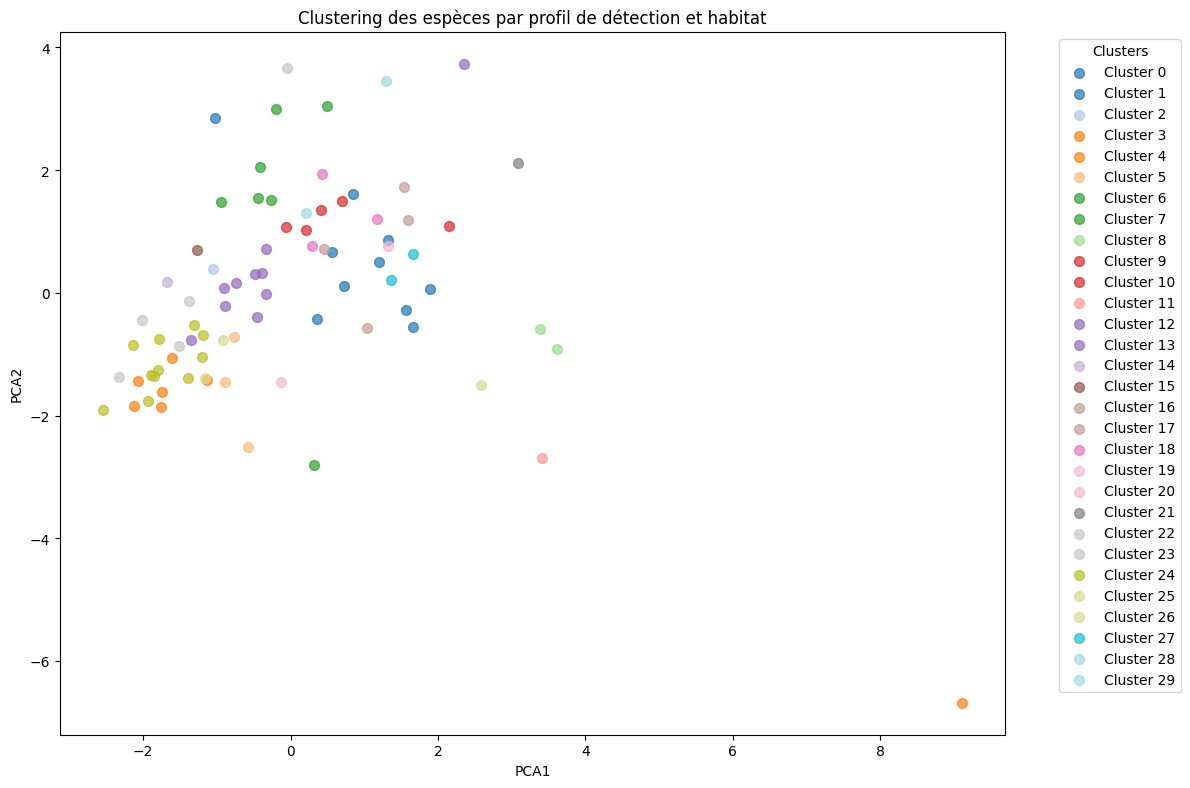

In [ ]:
# Réduction à 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

kmeans = KMeans(n_clusters=30, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(12,8))

n_clusters = len(np.unique(clusters))
# Palette de couleurs continue
colors = cm.get_cmap('tab20', n_clusters)  # 'tab20' permet plus de couleurs, interpolé si >20

for cluster_id in range(n_clusters):
    mask = clusters == cluster_id
    plt.scatter(
        X_pca[mask,0],
        X_pca[mask,1],
        color=colors(cluster_id),
        label=f'Cluster {cluster_id}',
        s=50, alpha=0.7
    )

plt.xlabel('PCA1')
plt.ylabel('PCA2')
#for i, name in enumerate(df_species_cluster.index):
#    plt.text(X_pca[i,0], X_pca[i,1], name, fontsize=8)
plt.title('Clustering des espèces par profil de détection et habitat')
plt.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')  # légende à droite
plt.tight_layout()
plt.show()


## Cartes

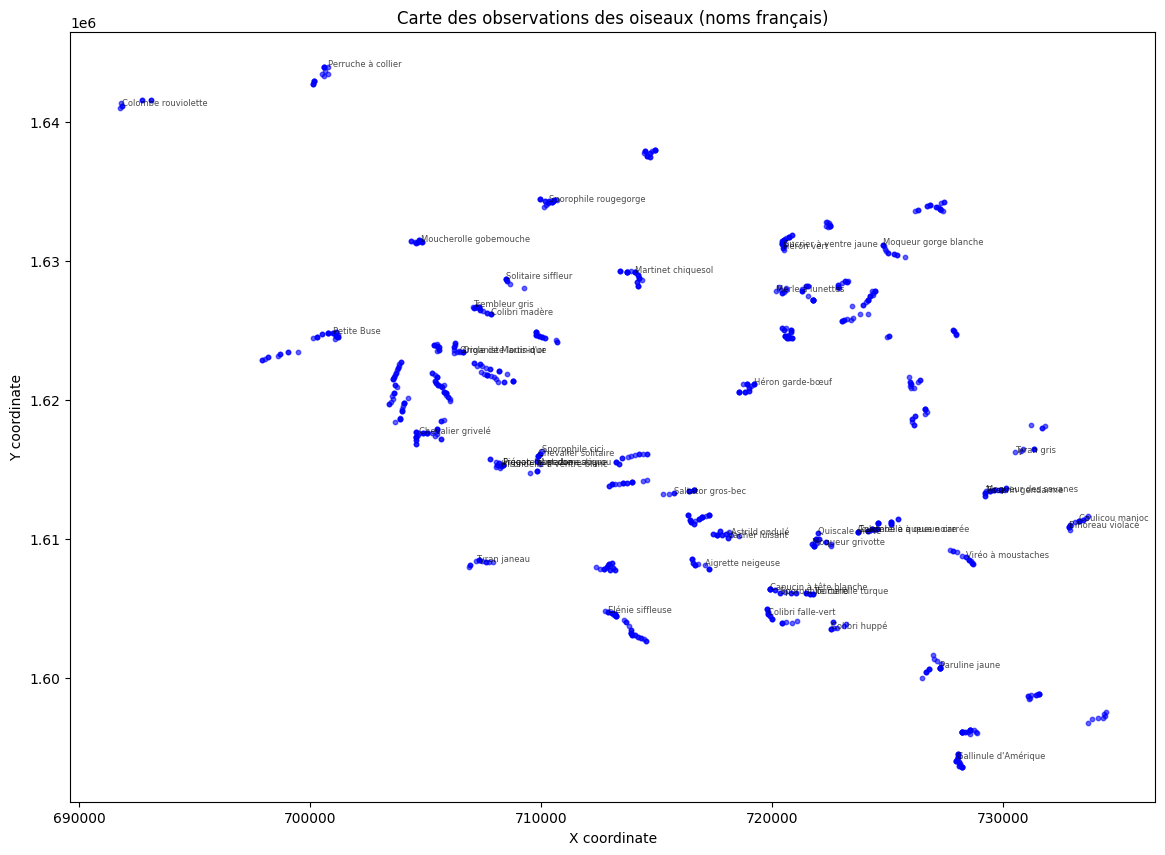

In [ ]:
plt.figure(figsize=(14, 10))

df_map_sample = df_full.dropna(subset=['X', 'Y', 'french_name']).sample(1000, random_state=42)

plt.scatter(df_map_sample['X'], df_map_sample['Y'], s=10, alpha=0.6, color='blue')

for name, group in df_map_sample.groupby('french_name'):
    first = group.iloc[0]
    plt.text(first['X'], first['Y'], name, fontsize=6, alpha=0.7)

plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.title("Carte des observations des oiseaux (noms français)")
plt.show()


C:\Users\zizou\AppData\Local\Temp\ipykernel_3392\805912064.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', len(habitats))


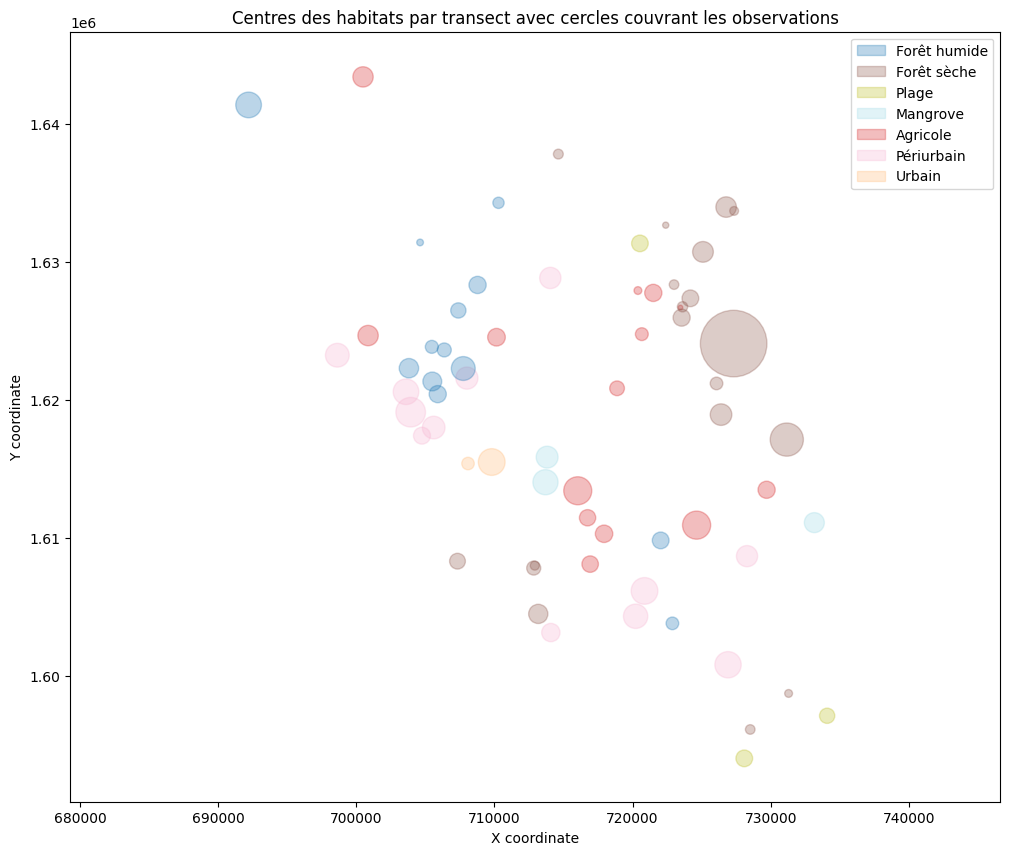

In [ ]:
df_map = df_full.dropna(subset=['X', 'Y', 'habitat'])

habitats = df_map['habitat'].unique()
colors = plt.cm.get_cmap('tab20', len(habitats))
habitat_color = {hab: colors(i) for i, hab in enumerate(habitats)}

plt.figure(figsize=(12, 10))

df_map_grouped = df_map.groupby(['transect', 'habitat'])

for (transect, hab), df_h in df_map_grouped:
    center_x = df_h['X'].mean()
    center_y = df_h['Y'].mean()
    radius = max(np.sqrt((df_h['X'] - center_x)**2 + (df_h['Y'] - center_y)**2))
    
    circle = plt.Circle((center_x, center_y), radius, 
                        color=habitat_color[hab], alpha=0.3, label=hab)
    plt.gca().add_patch(circle)
    
    #plt.scatter(center_x, center_y, color=habitat_color[hab], edgecolor='k', s=50)

plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.title("Centres des habitats par transect avec cercles couvrant les observations")

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), markerscale=2)

plt.axis('equal')  
plt.show()


C:\Users\zizou\AppData\Local\Temp\ipykernel_3392\1509554875.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', len(habitats))


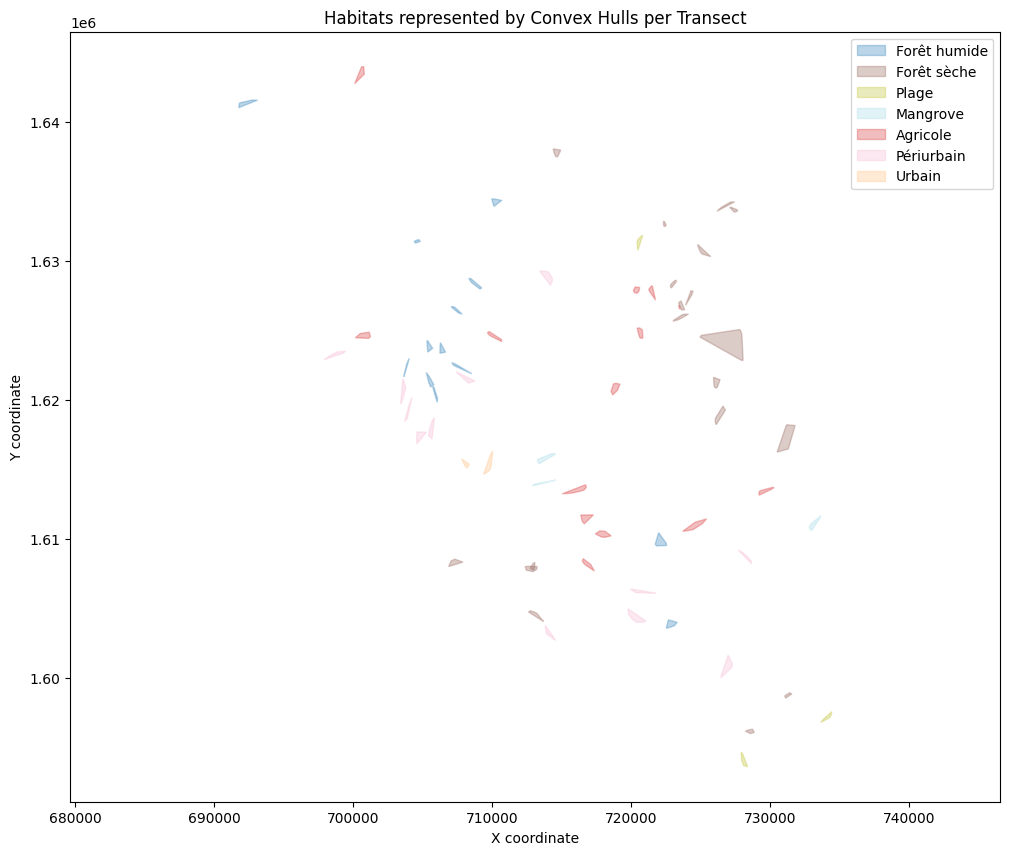

In [ ]:
from scipy.spatial import ConvexHull

df_map = df_full.dropna(subset=['X', 'Y', 'habitat'])

habitats = df_map['habitat'].unique()
colors = plt.cm.get_cmap('tab20', len(habitats))
habitat_color = {hab: colors(i) for i, hab in enumerate(habitats)}

plt.figure(figsize=(12, 10))

df_map_grouped = df_map.groupby(['transect', 'habitat'])

for (transect, hab), df_h in df_map_grouped:
    points = df_h[['X', 'Y']].values
    
    if len(points) >= 3:
        hull = ConvexHull(points)
        plt.fill(points[hull.vertices,0], points[hull.vertices,1], 
                color=habitat_color[hab], alpha=0.3, label=hab)
    
    center_x = points[:,0].mean()
    center_y = points[:,1].mean()
    #plt.scatter(center_x, center_y, color=habitat_color[hab], edgecolor='k', s=50)

plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.title("Habitats represented by Convex Hulls per Transect")
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), markerscale=2)

plt.axis('equal')
plt.show()



C:\Users\zizou\AppData\Local\Temp\ipykernel_3392\3243501194.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', len(habitats))
C:\Users\zizou\AppData\Local\Temp\ipykernel_3392\3243501194.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  species_colors = plt.cm.get_cmap('tab20b', len(species))


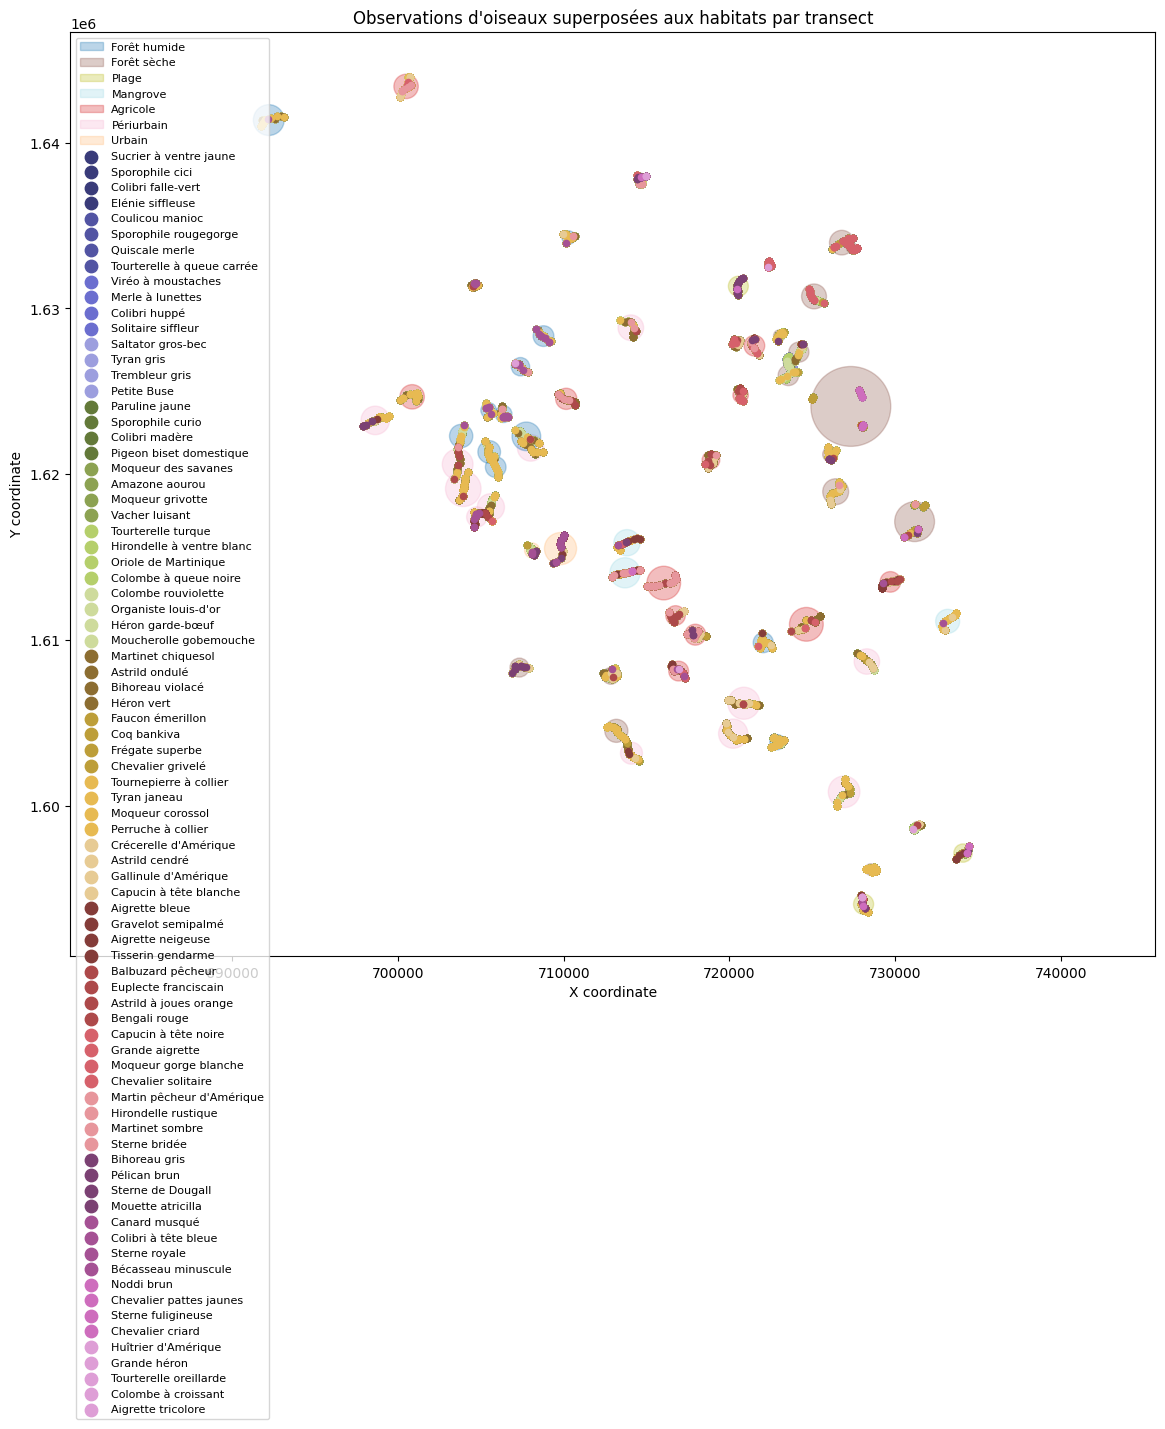

In [ ]:
colors = plt.cm.get_cmap('tab20', len(habitats))
habitat_color = {hab: colors(i) for i, hab in enumerate(habitats)}

species = df_map['french_name'].unique()
species_colors = plt.cm.get_cmap('tab20b', len(species))
species_color = {sp: species_colors(i) for i, sp in enumerate(species)}

plt.figure(figsize=(14, 12))

df_map_grouped = df_map.groupby(['transect', 'habitat'])
for (transect, hab), df_h in df_map_grouped:
    center_x = df_h['X'].mean()
    center_y = df_h['Y'].mean()
    radius = max(np.sqrt((df_h['X'] - center_x)**2 + (df_h['Y'] - center_y)**2))
    
    circle = plt.Circle((center_x, center_y), radius, 
                        color=habitat_color[hab], alpha=0.3, label=hab)
    plt.gca().add_patch(circle)

for sp in species:
    df_sp = df_map[df_map['french_name'] == sp]
    plt.scatter(df_sp['X'], df_sp['Y'], 
                color=species_color[sp], s=20, label=sp)

plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.title("Observations d'oiseaux superposées aux habitats par transect")

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), markerscale=2, fontsize=8)

plt.axis('equal')
plt.show()


# Tentatives plus esthétiques (pas au point)

In [ ]:
import plotly.express as px

df_map = df_full.dropna(subset=['X', 'Y', 'french_name', 'habitat']).sample(
    n=min(10000, len(df_full)), random_state=42
)

df_map['species_color'] = df_map['french_name']

fig = px.scatter(
    df_map,
    x='X',
    y='Y',
    color='species_color',       
    hover_name='french_name',    
    hover_data=['habitat'],      
    title='Sampled observations of birds with habitats',
    width=1200,
    height=800
)

for i, hab in enumerate(df_map['habitat'].unique()):
    df_h = df_map[df_map['habitat'] == hab]
    fig.add_shape(
        type='rect',
        x0=df_h['X'].min(),
        y0=df_h['Y'].min(),
        x1=df_h['X'].max(),
        y1=df_h['Y'].max(),
        fillcolor=px.colors.qualitative.Pastel[i % 10],
        opacity=0.2,
        line_width=0,
        layer='below'  
    )

fig.update_layout(
    xaxis_title='X coordinate',
    yaxis_title='Y coordinate',
    legend_title='Species',
)
fig.show()


In [ ]:
df_obs_map = df_full.dropna(subset=['X','Y','french_name','habitat'])

habitat_colors = {
    'Forêt humide': 'forestgreen',
    'Urbain': 'lightgrey',
    'Agricole': 'sandybrown',
    'Forêt sèche': 'gold',
    'Périurbain': 'silver',
    'Plage': 'lightyellow',
    'Mangrove': 'green'
}

df_transects = df_gps.groupby('transect').agg(
    X_min=('X','min'), X_max=('X','max'),
    Y_min=('Y','min'), Y_max=('Y','max'),
    habitat=('habitat','first')
).sort_values('X_min').reset_index()

fig = px.scatter(
    df_obs_map,
    x='X', y='Y',
    color='french_name',
    hover_name='french_name',
    width=1200, height=800,
    title='Observations des oiseaux avec fond habitats entièrement rempli'
)

for i, row in df_transects.iterrows():
    color = habitat_colors[row['habitat']]
    fig.add_shape(
        type='rect',
        x0=row['X_min'],
        y0=row['Y_min'],
        x1=row['X_max'],
        y1=row['Y_max'],
        fillcolor=color,
        line_width=0,
        layer='below'
    )
    if i < len(df_transects)-1:
        next_row = df_transects.iloc[i+1]
        mid_x = (row['X_max'] + next_row['X_min']) / 2
        fig.add_shape(
            type='rect',
            x0=row['X_max'],
            y0=row['Y_min'],
            x1=mid_x,
            y1=row['Y_max'],
            fillcolor=color,
            line_width=0,
            layer='below'
        )
        next_color = habitat_colors[next_row['habitat']]
        fig.add_shape(
            type='rect',
            x0=mid_x,
            y0=row['Y_min'],
            x1=next_row['X_min'],
            y1=row['Y_max'],
            fillcolor=next_color,
            line_width=0,
            layer='below'
        )

fig.update_layout(
    xaxis_title='X',
    yaxis_title='Y',
    legend_title='Espèces'
)

fig.show()


In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Sélection des top observateurs/transects
top_observers = df_full['observer'].value_counts().nlargest(10).index
top_transects = df_full['transect'].value_counts().nlargest(10).index

df_small = df_full[df_full['observer'].isin(top_observers) & 
            df_full['transect'].isin(top_transects)].copy()

# Créer total_detections et year
df_small['total_detections'] = df_small['auditory_total'].fillna(0) + df_small['visual__no_flight_total'].fillna(0)
df_small['year'] = df_small['date'].dt.year

# Fit GLM
model = smf.glm("total_detections ~ observer + transect + year",
                data=df_small,
                family=sm.families.Poisson()).fit()

print(model.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:       total_detections   No. Observations:                16904
Model:                            GLM   Df Residuals:                    16891
Model Family:                 Poisson   Df Model:                           12
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -31509.
Date:                Fri, 31 Oct 2025   Deviance:                       20532.
Time:                        00:52:39   Pearson chi2:                 2.98e+04
No. Iterations:                     5   Pseudo R-squ. (CS):            0.01923
Covariance Type:            nonrobust                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

df_full['total_detections'] = df_full['auditory_total'].fillna(0) + df_full['visual__no_flight_total'].fillna(0)
df_full['year'] = df_full['date'].dt.year

# Modèle mixte
md = smf.mixedlm("total_detections ~ year", 
        data=df_full,
        groups=df_full["transect"], 
        re_formula="~observer")

mdf = md.fit()
print(mdf.summary())
